# Laboratorio Integrador — Explicabilidad de un Agente de Razonamiento Empresarial

**Estudiante:** Hugo Israel Gavilima  
**Asignatura:** Inteligencia Artificial Avanzada — Módulo de Interpretabilidad  
**Dataset:** Base de conocimiento y señales internas del Business Reasoning Agent de PayNova S.A.  

---

## Descripción del Experimento

Este laboratorio evalúa un **agente de razonamiento empresarial** basado en arquitectura **ReAct + Multi-Hop** sobre documentación interna de PayNova S.A., utilizando las siguientes metodologías:

1. **Evaluación con RAGAS** — métricas de retrieval-augmented generation: Faithfulness, Answer Relevancy, Context Precision y Context Recall sobre 40 preguntas de benchmark.
2. **Técnicas de Interpretabilidad** — SHAP (SHapley Additive exPlanations) y explicaciones contrafactuales (DiCE) sobre un meta-clasificador entrenado con las señales internas del agente.

**Objetivo:** Evaluar y explicar el comportamiento del agente mediante métricas objetivas e interpretabilidad del aprendizaje automático.

**Valor:** 25 puntos

## Configuración del Entorno

In [10]:
import sys, os, re, time, json, warnings
from pathlib import Path

# ── Raíz del proyecto al path ─────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# ── Variables de entorno desde .env ──────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

_required = ["OPENAI_KEY", "LLM_MODEL", "LLM_BASE_URL", "PG_HOST", "PG_DATABASE"]
_missing  = [v for v in _required if not os.getenv(v)]
if _missing:
    raise EnvironmentError(f"Variables de entorno faltantes en .env: {_missing}")
print("✅ Variables de entorno cargadas.")

# ── Librerías ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLOR_PALETTE = sns.color_palette("Blues_r", 8)

print(f"✅ Librerías cargadas. Python: {sys.version.split()[0]} | pandas: {pd.__version__}")

✅ Variables de entorno cargadas.
✅ Librerías cargadas. Python: 3.14.4 | pandas: 3.0.3


## Carga del Agente

In [11]:
from agente.pipeline.react_loop import BusinessReasoningAgent
from agente.knowledge.retriever import BusinessKnowledgeRetriever

print("Inicializando Business Reasoning Agent...")
agent = BusinessReasoningAgent(force_rebuild_kb=False)

# Acceso directo al retriever para capturar contextos (necesario para RAGAS)
kb_retriever = agent.kb_retriever

print("✅ Agente inicializado.")
print(f"   Chunks indexados en KB: {len(kb_retriever._chunks)}")

Inicializando Business Reasoning Agent...
[ReAct] Inicializando Business Reasoning Agent (Arquitectura Evolucionada)...
[KB Retriever] Índice cargado (335 chunks).
[ReAct] Agente evolucionado listo.
✅ Agente inicializado.
   Chunks indexados en KB: 335


## Carga de la Base de Preguntas (Benchmark)

Se cargan las 40 preguntas y sus ground truths desde `textos/preguntas_kb.txt`.  
Cada par tiene el formato:
```
P01: <pregunta>
GT01: <ground truth>
```

In [12]:
TXT_PATH = PROJECT_ROOT / "textos" / "preguntas_kb.txt"

questions, ground_truths, ids = [], [], []

with open(TXT_PATH, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        # Líneas de pregunta: P01:, P02:, ... P40:
        m_q = re.match(r'^(P\d{2}):\s+(.+)$', line)
        if m_q:
            ids.append(m_q.group(1))
            questions.append(m_q.group(2))
        # Líneas de ground truth: GT01:, GT02:, ...
        m_gt = re.match(r'^GT\d{2}:\s+(.+)$', line)
        if m_gt:
            ground_truths.append(m_gt.group(1))

assert len(questions) == 40, f"Se esperaban 40 preguntas, se encontraron {len(questions)}"
assert len(ground_truths) == 40, f"Se esperaban 40 GTs, se encontraron {len(ground_truths)}"

df_questions = pd.DataFrame({
    "id":           ids,
    "question":     questions,
    "ground_truth": ground_truths,
    "q_length":     [len(q.split()) for q in questions],
}).iloc[0:15] # Solo las primeras 15 preguntas para pruebas rápidas

print(f"✅ {len(df_questions)} preguntas cargadas desde {TXT_PATH.name}")
print(f"   Longitud promedio de pregunta: {df_questions['q_length'].mean():.1f} palabras")
print()
display(df_questions[["id", "question", "q_length"]].head(10))

✅ 15 preguntas cargadas desde preguntas_kb.txt
   Longitud promedio de pregunta: 19.0 palabras



,id,question,q_length
0,P01,"¿Qué es PayNova S.A., cuáles son sus roles sim...",22
1,P02,¿Cómo funciona el modelo de plataforma de dos ...,18
2,P03,¿Cuáles son las cuatro fuentes de ingresos de ...,15
3,P04,¿Cuáles son los siete objetivos estratégicos d...,15
4,P05,¿Cuáles son los segmentos de mercado atendidos...,20
5,P06,¿Cuál es la diferencia conceptual y de cálculo...,19
6,P07,¿Por qué está prohibido usar SUM(monto) para c...,20
7,P08,¿Cómo se calcula el margen neto ajustado de Pa...,17
8,P09,¿Cuáles son las tasas de comisión de payout po...,23
9,P10,¿Cuáles son los costos unitarios de cada canal...,22


## Ejecución del Agente sobre el Benchmark

Se ejecuta el agente sobre cada una de las 40 preguntas. Los resultados se persisten en `textos/agent_results.csv` para evitar re-ejecuciones costosas (`force_rerun=False` usa la caché si existe).

Por cada respuesta se capturan:
- `answer` — resumen ejecutivo generado
- `context` — chunks recuperados de la KB (para RAGAS)
- `confidence_score` — score compuesto (0–100)
- `kb_was_sufficient` — si respondió directamente desde la KB
- `critic_verdict` — veredicto del agente crítico

In [6]:
RESULTS_CSV = PROJECT_ROOT / "textos" / "agent_results.csv"

def run_agent_on_questions(df: pd.DataFrame, force_rerun: bool = False) -> pd.DataFrame:
    """Ejecuta el agente sobre todas las preguntas. Usa caché CSV si existe."""
    if RESULTS_CSV.exists() and not force_rerun:
        print(f"📂 Cargando resultados desde caché: {RESULTS_CSV.name}")
        return pd.read_csv(RESULTS_CSV)

    records = []
    n = len(df)
    for i, row in df.iterrows():
        t0 = time.time()
        print(f"[{i+1:02d}/{n}] {row['question'][:65]}...")
        try:
            resp = agent.answer(row["question"], verbose=False)
            ctx  = kb_retriever.retrieve_formatted(row["question"], top_k=5)
            comps = resp.confidence_components or {}
            records.append({
                "id":                row["id"],
                "question":          row["question"],
                "ground_truth":      row["ground_truth"],
                "answer":            resp.executive_summary,
                "context":           ctx,
                "kb_was_sufficient": int(resp.kb_was_sufficient),
                "critic_verdict":    resp.critic_verdict,
                "confidence_score":  resp.confidence_score,
                "c_retrieval":       comps.get("retrieval", 85),
                "c_plan":            comps.get("plan", 70),
                "c_sql":             comps.get("sql", 75),
                "c_business":        comps.get("business", 80),
                "c_critic":          comps.get("critic", 75),
                "c_iter_penalty":    comps.get("iter_penalty", 0),
                "q_length":          row["q_length"],
                "answer_length":     len(resp.executive_summary.split()),
                "elapsed_s":         round(time.time() - t0, 2),
            })
        except Exception as e:
            print(f"  ⚠️  Error: {e}")
            records.append({
                "id": row["id"], "question": row["question"],
                "ground_truth": row["ground_truth"],
                "answer": f"ERROR: {e}", "context": "",
                "kb_was_sufficient": 0, "critic_verdict": "sufficient",
                "confidence_score": 40, "c_retrieval": 50, "c_plan": 50,
                "c_sql": 30, "c_business": 50, "c_critic": 40,
                "c_iter_penalty": 10, "q_length": row["q_length"],
                "answer_length": 0, "elapsed_s": round(time.time() - t0, 2),
            })
        r = records[-1]
        print(f"       conf={r['confidence_score']}/100  "
              f"kb_direct={bool(r['kb_was_sufficient'])}  "
              f"critic={r['critic_verdict']}  ({r['elapsed_s']}s)")

    df_out = pd.DataFrame(records)
    df_out.to_csv(RESULTS_CSV, index=False)
    print(f"\n✅ Resultados guardados en {RESULTS_CSV.name}")
    return df_out


df_results = run_agent_on_questions(df_questions, force_rerun=False)
print(f"\nShape: {df_results.shape}")
print(f"Confidence score promedio: {df_results['confidence_score'].mean():.1f}/100")
print(f"% KB-directas: {df_results['kb_was_sufficient'].mean()*100:.1f}%")
print(f"% Critic sufficient: {(df_results['critic_verdict']=='sufficient').mean()*100:.1f}%")
print(f"Tiempo total: {df_results['elapsed_s'].sum():.1f}s")

display(df_results[["id", "confidence_score", "kb_was_sufficient",
                    "critic_verdict", "elapsed_s"]].head(10))

[01/40] ¿Qué es PayNova S.A., cuáles son sus roles simultáneos en el ecos...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4728.95it/s]


       conf=98/100  kb_direct=True  critic=sufficient  (23.92s)
[02/40] ¿Cómo funciona el modelo de plataforma de dos lados de PayNova y ...
       conf=96/100  kb_direct=True  critic=sufficient  (16.92s)
[03/40] ¿Cuáles son las cuatro fuentes de ingresos de PayNova y qué porce...
       conf=77/100  kb_direct=False  critic=replan  (67.23s)
[04/40] ¿Cuáles son los siete objetivos estratégicos de PayNova, sus métr...
       conf=66/100  kb_direct=False  critic=retry_sql  (224.9s)
[05/40] ¿Cuáles son los segmentos de mercado atendidos por PayNova y qué ...
       conf=66/100  kb_direct=False  critic=replan  (242.24s)
[06/40] ¿Cuál es la diferencia conceptual y de cálculo entre GMV, ingreso...
       conf=88/100  kb_direct=False  critic=sufficient  (140.93s)
[07/40] ¿Por qué está prohibido usar SUM(monto) para calcular los ingreso...
       conf=92/100  kb_direct=True  critic=sufficient  (16.2s)
[08/40] ¿Cómo se calcula el margen neto ajustado de PayNova y qué costos ...
       conf=98/10

KeyboardInterrupt: 

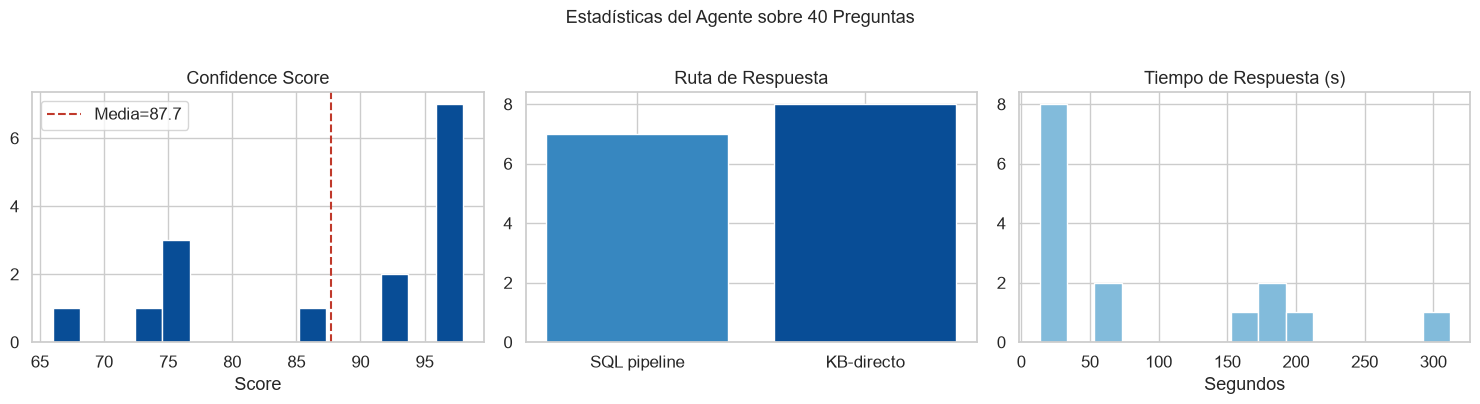

In [13]:
# ── Estadísticas descriptivas del benchmark ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribución de confidence score
axes[0].hist(df_results["confidence_score"], bins=15, color=COLOR_PALETTE[0],
             edgecolor="white")
axes[0].axvline(df_results["confidence_score"].mean(), color="#c0392b",
                linestyle="--", label=f"Media={df_results['confidence_score'].mean():.1f}")
axes[0].set_title("Confidence Score"); axes[0].set_xlabel("Score"); axes[0].legend()

# 2. KB-directo vs SQL
kb_counts = df_results["kb_was_sufficient"].value_counts()
axes[1].bar(["SQL pipeline", "KB-directo"],
            [kb_counts.get(0, 0), kb_counts.get(1, 0)],
            color=[COLOR_PALETTE[2], COLOR_PALETTE[0]])
axes[1].set_title("Ruta de Respuesta")

# 3. Distribución de tiempos
axes[2].hist(df_results["elapsed_s"], bins=15, color=COLOR_PALETTE[4],
             edgecolor="white")
axes[2].set_title("Tiempo de Respuesta (s)"); axes[2].set_xlabel("Segundos")

plt.suptitle("Estadísticas del Agente sobre 40 Preguntas", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Punto 2: Evaluación del Agente con Métricas de Similitud Semántica

Se aproximan las 4 métricas equivalentes a RAGAS usando **similitud coseno entre embeddings** del modelo `all-MiniLM-L6-v2` (el mismo que usa el agente internamente, sin costo adicional de API):

| Métrica | Cálculo | Interpreta |
|---------|---------|------------|
| **Faithfulness** | `cos_sim(answer, context)` | ¿La respuesta está respaldada por el contexto recuperado? |
| **Answer Relevancy** | `cos_sim(question, answer)` | ¿La respuesta es pertinente a la pregunta? |
| **Context Precision** | `cos_sim(question, context)` | ¿El contexto recuperado es relevante para la pregunta? |
| **Context Recall** | `cos_sim(ground_truth, context)` | ¿El contexto cubre la información del ground truth? |

Rango: 0–1, mayor es mejor.

In [14]:
from sentence_transformers import SentenceTransformer, util

METRICS_CSV   = PROJECT_ROOT / "textos" / "semantic_scores.csv"
RAGAS_METRICS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

def compute_semantic_scores(df: pd.DataFrame, force_rerun: bool = False) -> pd.DataFrame:
    """Calcula métricas de calidad usando similitud coseno entre embeddings."""
    if METRICS_CSV.exists() and not force_rerun:
        print(f"📂 Cargando scores desde caché: {METRICS_CSV.name}")
        return pd.read_csv(METRICS_CSV)

    print("Cargando modelo de embeddings all-MiniLM-L6-v2...")
    emb_model = SentenceTransformer("all-MiniLM-L6-v2")

    def cos_sim(text_a: str, text_b: str) -> float:
        if not text_a or not text_b:
            return 0.0
        embs = emb_model.encode([str(text_a), str(text_b)], convert_to_tensor=True)
        return float(util.cos_sim(embs[0], embs[1]))

    print(f"Calculando métricas para {len(df)} respuestas...")
    records = []
    for i, row in df.iterrows():
        q   = row["question"]
        a   = row["answer"]
        ctx = row["context"] if pd.notna(row["context"]) else ""
        gt  = row["ground_truth"]
        records.append({
            "id":                row["id"],
            "faithfulness":      cos_sim(a,  ctx),   # ¿respuesta respaldada por contexto?
            "answer_relevancy":  cos_sim(q,  a),     # ¿respuesta pertinente a la pregunta?
            "context_precision": cos_sim(q,  ctx),   # ¿contexto relevante para la pregunta?
            "context_recall":    cos_sim(gt, ctx),   # ¿contexto cubre el ground truth?
        })
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(df)} procesadas")

    df_scores = pd.DataFrame(records)
    df_scores.to_csv(METRICS_CSV, index=False)
    print(f"✅ Scores guardados en {METRICS_CSV.name}")
    return df_scores


df_ragas = compute_semantic_scores(df_results, force_rerun=False)

print("\n📊 Resumen de métricas:")
display(df_ragas[RAGAS_METRICS].describe().round(4))

Cargando modelo de embeddings all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4140.68it/s]


Calculando métricas para 15 respuestas...
  10/15 procesadas
✅ Scores guardados en semantic_scores.csv

📊 Resumen de métricas:


,faithfulness,answer_relevancy,context_precision,context_recall
count,15.0000,15.0000,15.0000,15.0000
mean,0.5690,0.6798,0.5935,0.5890
std,0.1056,0.0931,0.0515,0.1176
min,0.3990,0.4965,0.4722,0.4057
25%,0.4685,0.6238,0.5619,0.5053
50%,0.6030,0.6684,0.6051,0.5806
75%,0.6641,0.7448,0.6252,0.6935
max,0.7023,0.8379,0.6682,0.7739


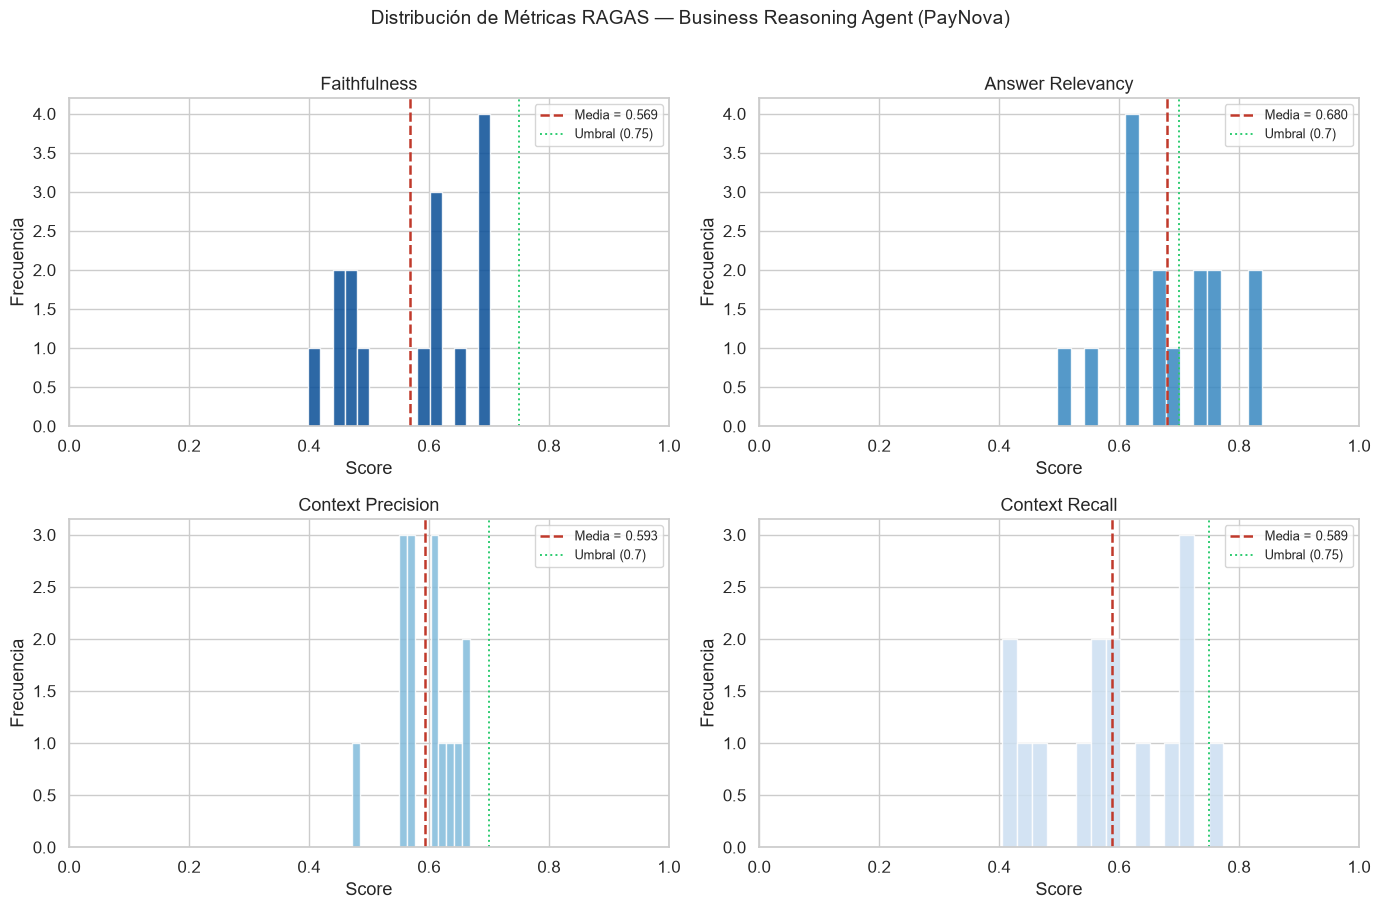

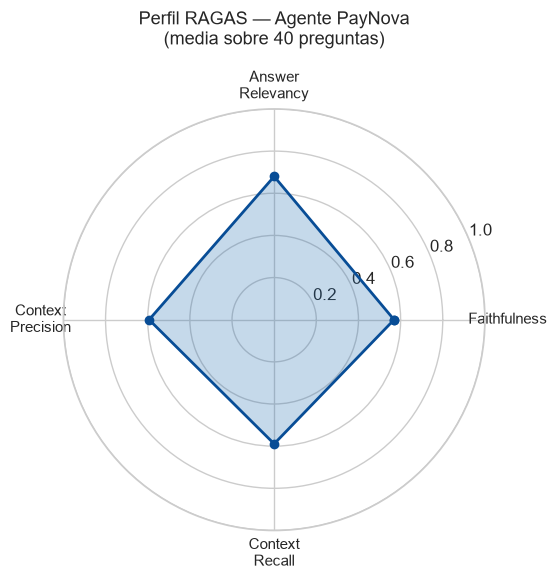

,Media,Mediana,Std,Min,Max,Umbral,% sobre umbral
Métrica,,,,,,,
Faithfulness,0.5690,0.6030,0.1056,0.3990,0.7023,0.75,0.0%
Answer Relevancy,0.6798,0.6684,0.0931,0.4965,0.8379,0.70,40.0%
Context Precision,0.5935,0.6051,0.0515,0.4722,0.6682,0.70,0.0%
Context Recall,0.5890,0.5806,0.1176,0.4057,0.7739,0.75,6.7%


In [15]:
# ── Distribución de cada métrica RAGAS ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
labels = ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]
thresholds = [0.75, 0.70, 0.70, 0.75]

for ax, metric, label, thresh, color in zip(
    axes, RAGAS_METRICS, labels, thresholds,
    [COLOR_PALETTE[0], COLOR_PALETTE[2], COLOR_PALETTE[4], COLOR_PALETTE[6]]
):
    vals = df_ragas[metric].dropna()
    ax.hist(vals, bins=15, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="#c0392b", linestyle="--", linewidth=1.8,
               label=f"Media = {vals.mean():.3f}")
    ax.axvline(thresh, color="#2ecc71", linestyle=":", linewidth=1.4,
               label=f"Umbral ({thresh})")
    ax.set_title(label, fontsize=13)
    ax.set_xlabel("Score"); ax.set_ylabel("Frecuencia")
    ax.set_xlim(0, 1); ax.legend(fontsize=9)

plt.suptitle("Distribución de Métricas RAGAS — Business Reasoning Agent (PayNova)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Radar chart de medias ─────────────────────────────────────────────────────
means = df_ragas[RAGAS_METRICS].mean()
angles = np.linspace(0, 2*np.pi, len(RAGAS_METRICS), endpoint=False).tolist()
vals_r = means.tolist() + [means.tolist()[0]]
angles_r = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
ax.plot(angles_r, vals_r, "o-", color=COLOR_PALETTE[0], linewidth=2)
ax.fill(angles_r, vals_r, alpha=0.25, color=COLOR_PALETTE[1])
ax.set_xticks(angles)
ax.set_xticklabels(["Faithfulness", "Answer\nRelevancy",
                    "Context\nPrecision", "Context\nRecall"], fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Perfil RAGAS — Agente PayNova\n(media sobre 40 preguntas)", pad=18)
plt.tight_layout()
plt.show()

# ── Tabla resumen ─────────────────────────────────────────────────────────────
resumen = pd.DataFrame({
    "Métrica": labels,
    "Media":   [df_ragas[m].mean() for m in RAGAS_METRICS],
    "Mediana": [df_ragas[m].median() for m in RAGAS_METRICS],
    "Std":     [df_ragas[m].std() for m in RAGAS_METRICS],
    "Min":     [df_ragas[m].min() for m in RAGAS_METRICS],
    "Max":     [df_ragas[m].max() for m in RAGAS_METRICS],
    "Umbral":  thresholds,
    "% sobre umbral": [
        f"{(df_ragas[m] >= t).mean()*100:.1f}%"
        for m, t in zip(RAGAS_METRICS, thresholds)
    ],
}).round(4)
display(resumen.set_index("Métrica"))

# Punto 3: Técnicas de Explicabilidad

El LLM no es directamente interpretable con SHAP o DiCE porque no expone sus pesos internos. La estrategia estándar en XAI para LLMs es construir un **modelo proxy (caja negra)** entrenado sobre las señales observables del sistema, y aplicar las técnicas sobre ese proxy.

**Señales del agente usadas como features:**

| Feature | Descripción |
|---------|-------------|
| `c_retrieval` | Score de calidad de recuperación KB (0–100) |
| `c_plan` | Score de calidad del plan Multi-Hop (0–100) |
| `c_sql` | Score de calidad del SQL generado (0–100) |
| `c_business` | Score de validación de reglas de negocio (0–100) |
| `c_critic` | Score del agente crítico independiente (0–100) |
| `c_iter_penalty` | Penalización por número de iteraciones (0–100) |
| `kb_was_sufficient` | Respondió directamente desde KB (0/1) |
| `confidence_score` | Score compuesto final (0–100) |

**Variable objetivo:** `quality_class` — 1 (alta calidad) si `faithfulness` y `answer_relevancy` están ambas por encima de su mediana.

Dataset: (15, 12)  |  Alta calidad: 6  |  Baja calidad: 9
Umbrales — faithfulness ≥ 0.603  |  answer_relevancy ≥ 0.668

AUC-ROC CV-5: 0.7500 ± 0.3873
AUC-ROC test: 0.5000

              precision    recall  f1-score   support

        Baja       1.00      0.50      0.67         2
        Alta       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



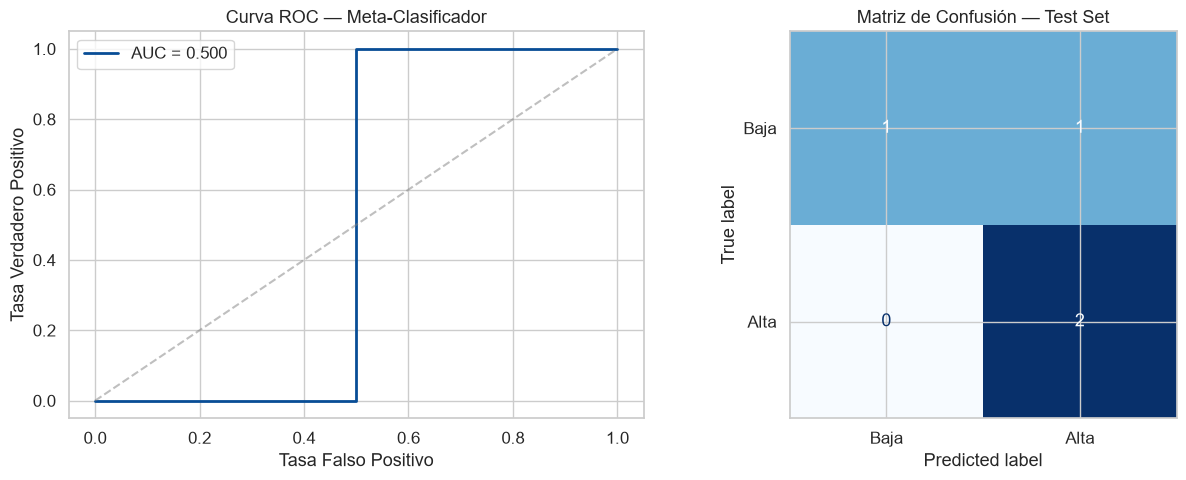

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix, roc_curve

# ── Dataset: combinar señales del agente + métricas de calidad ────────────────
SIGNAL_COLS = ["c_retrieval", "c_plan", "c_sql", "c_business",
               "c_critic", "c_iter_penalty", "kb_was_sufficient", "confidence_score"]

df_ml = df_results[["id"] + SIGNAL_COLS].merge(
    df_ragas[["id", "faithfulness", "answer_relevancy"]], on="id"
)

# Etiqueta: alta calidad si ambas métricas superan su mediana
thresh_f  = df_ml["faithfulness"].median()
thresh_ar = df_ml["answer_relevancy"].median()
df_ml["quality_class"] = (
    (df_ml["faithfulness"]     >= thresh_f) &
    (df_ml["answer_relevancy"] >= thresh_ar)
).astype(int)

print(f"Dataset: {df_ml.shape}  |  Alta calidad: {df_ml['quality_class'].sum()}  "
      f"|  Baja calidad: {(df_ml['quality_class']==0).sum()}")
print(f"Umbrales — faithfulness ≥ {thresh_f:.3f}  |  answer_relevancy ≥ {thresh_ar:.3f}")

# ── Entrenamiento del meta-clasificador ───────────────────────────────────────
X = df_ml[SIGNAL_COLS].values
y = df_ml["quality_class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200, max_depth=6, min_samples_leaf=2,
    class_weight="balanced", random_state=42,
)
clf.fit(X_train, y_train)

cv_auc  = cross_val_score(clf, X, y, cv=StratifiedKFold(5), scoring="roc_auc")
y_prob  = clf.predict_proba(X_test)[:, 1]
y_pred  = clf.predict(X_test)

print(f"\nAUC-ROC CV-5: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"AUC-ROC test: {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Baja", "Alta"]))

# ── Curva ROC + Matriz de Confusión ───────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color=COLOR_PALETTE[0], lw=2,
             label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
axes[0].plot([0,1],[0,1], "--", color="gray", alpha=0.5)
axes[0].set(xlabel="Tasa Falso Positivo", ylabel="Tasa Verdadero Positivo",
            title="Curva ROC — Meta-Clasificador")
axes[0].legend()

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Baja", "Alta"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Matriz de Confusión — Test Set")
plt.tight_layout()
plt.show()

## 3.1 SHAP — SHapley Additive exPlanations

SHAP asigna a cada feature una contribución marginal al resultado del modelo, calculada como el promedio ponderado de las contribuciones marginales sobre todas las posibles coaliciones de features:

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$

Se usa **TreeExplainer** (algoritmo exacto y eficiente para RandomForest):
- **Global:** ¿Qué señales impactan más en general a la predicción de calidad?
- **Local:** ¿Por qué el modelo predice alta/baja calidad para una respuesta específica?

  SHAP GLOBAL — Beeswarm (impacto por instancia)


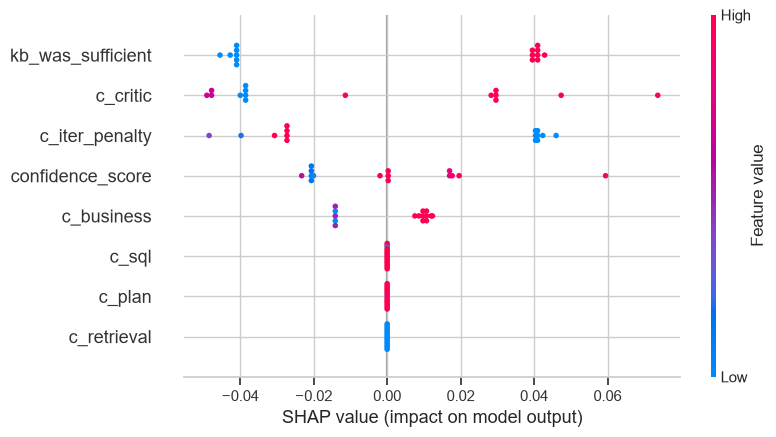


  SHAP GLOBAL — Importancia media (Mean |SHAP|)


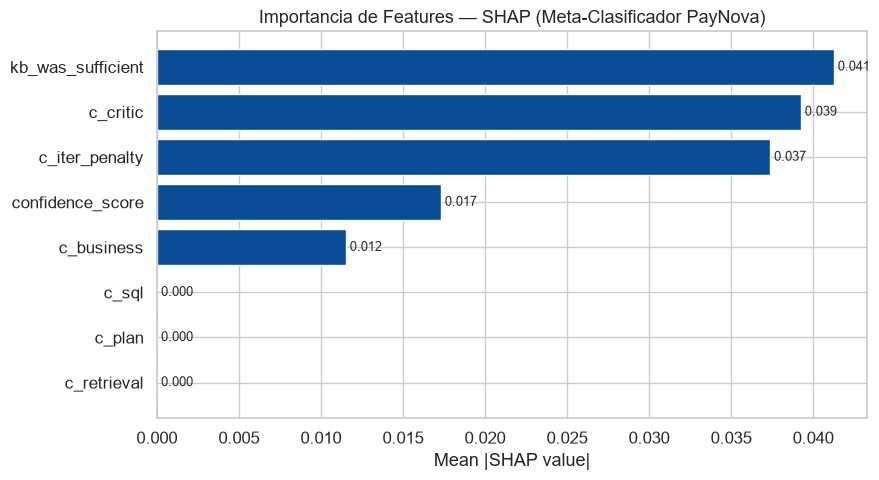


Ranking de señales por importancia SHAP:
  1. kb_was_sufficient      0.0412
  2. c_critic               0.0392
  3. c_iter_penalty         0.0374
  4. confidence_score       0.0173
  5. c_business             0.0115
  6. c_sql                  0.0000
  7. c_retrieval            0.0000
  8. c_plan                 0.0000


In [17]:
import shap

shap.initjs()

# ── TreeExplainer sobre el meta-clasificador ──────────────────────────────────
explainer   = shap.TreeExplainer(clf)
X_df        = pd.DataFrame(X, columns=SIGNAL_COLS)
shap_values = explainer(X_df)          # Explanation object (n_samples, n_features, n_classes)
sv_class1   = shap_values[:, :, 1]    # SHAP values para clase "Alta calidad"

# ── GLOBAL 1: Beeswarm summary plot ──────────────────────────────────────────
print("=" * 55)
print("  SHAP GLOBAL — Beeswarm (impacto por instancia)")
print("=" * 55)
shap.plots.beeswarm(sv_class1, max_display=len(SIGNAL_COLS), show=True)

# ── GLOBAL 2: Mean |SHAP| bar chart ──────────────────────────────────────────
print("\n" + "=" * 55)
print("  SHAP GLOBAL — Importancia media (Mean |SHAP|)")
print("=" * 55)
mean_shap = np.abs(sv_class1.values).mean(axis=0)
feat_importance = pd.Series(mean_shap, index=SIGNAL_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_importance.index, feat_importance.values, color=COLOR_PALETTE[0])
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Importancia de Features — SHAP (Meta-Clasificador PayNova)")
plt.tight_layout()
plt.show()

# Ranking textual
print("\nRanking de señales por importancia SHAP:")
for rank, (feat, val) in enumerate(feat_importance.sort_values(ascending=False).items(), 1):
    print(f"  {rank}. {feat:<22} {val:.4f}")


────────────────────────────────────────────────────────────
  Verdadero Positivo (Alta calidad)
  ID: P14  |  Real: Alta  |  P(Alta)=0.744
────────────────────────────────────────────────────────────


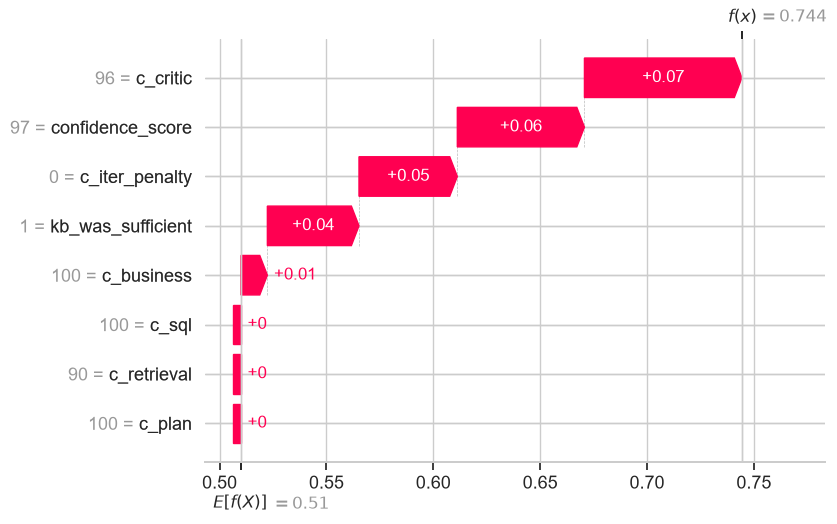


────────────────────────────────────────────────────────────
  Verdadero Negativo (Baja calidad)
  ID: P02  |  Real: Baja  |  P(Alta)=0.608
────────────────────────────────────────────────────────────


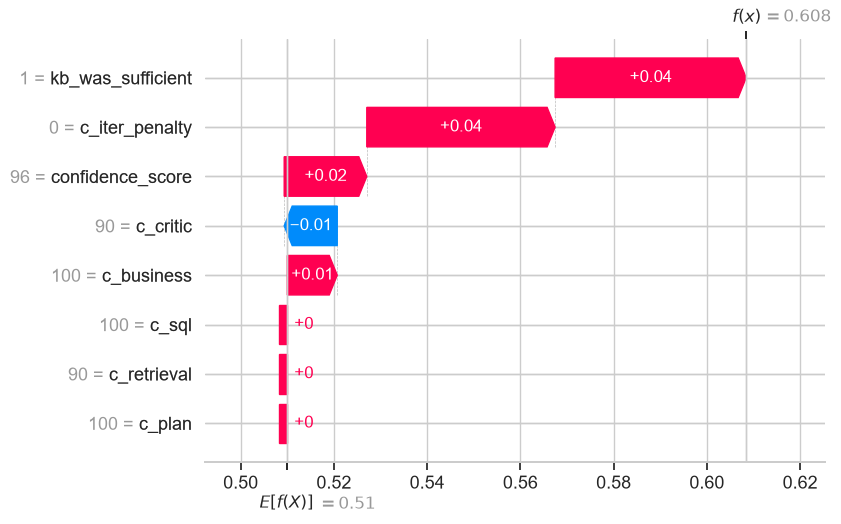


────────────────────────────────────────────────────────────
  Caso Incierto
  ID: P12  |  Real: Baja  |  P(Alta)=0.461
────────────────────────────────────────────────────────────


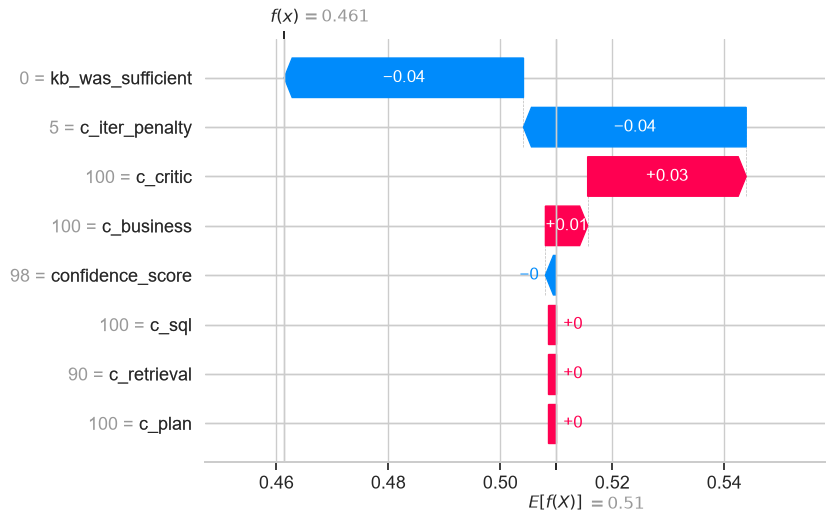

In [18]:
# ── SHAP LOCAL: Waterfall plots para 3 instancias representativas ─────────────
# Seleccionar: 1 verdadero positivo, 1 verdadero negativo, 1 caso incierto

probs_all = clf.predict_proba(X)[:, 1]

# Verdadero Positivo: alta calidad real Y predicha con alta confianza
tp_idx = [i for i in range(len(y))
          if y[i] == 1 and probs_all[i] >= 0.7]
# Verdadero Negativo: baja calidad real Y predicha con alta confianza
tn_idx = [i for i in range(len(y))
          if y[i] == 0 and probs_all[i] <= 0.3]
# Caso incierto: probabilidad cercana a 0.5
unc_idx = sorted(range(len(y)), key=lambda i: abs(probs_all[i] - 0.5))

cases = {
    "Verdadero Positivo (Alta calidad)": tp_idx[0]  if tp_idx  else 0,
    "Verdadero Negativo (Baja calidad)": tn_idx[0]  if tn_idx  else 1,
    "Caso Incierto":                     unc_idx[0],
}

for title, idx in cases.items():
    row    = df_ml.iloc[idx]
    pred_p = probs_all[idx]
    actual = "Alta" if y[idx] == 1 else "Baja"
    print(f"\n{'─'*60}")
    print(f"  {title}")
    print(f"  ID: {row['id']}  |  Real: {actual}  |  P(Alta)={pred_p:.3f}")
    print(f"{'─'*60}")
    shap.plots.waterfall(sv_class1[idx], max_display=len(SIGNAL_COLS), show=True)

## 3.2 Explicaciones Contrafactuales (DiCE)

Los contrafácticos responden: **¿qué cambio mínimo en las señales del agente haría que el modelo predijera alta calidad?**

Se usa **DiCE (Diverse Counterfactual Explanations)** con el meta-clasificador como caja negra. Para instancias de baja calidad, se generan 3 contrafácticos diversos que muestran caminos alternativos hacia una respuesta de alta calidad.

Esto es especialmente útil para identificar **qué componentes del agente se deben mejorar** para obtener mejores respuestas.

In [23]:
import dice_ml
from dice_ml import Dice

# ── Preparar datos para DiCE — todo float64 (fix compatibilidad pandas 2.x) ──
df_dice = X_df.copy().astype(float)
df_dice["quality_class"] = y.astype(float)

# DiCE trata kb_was_sufficient como continua para evitar el error de dtype
all_feats = SIGNAL_COLS  # todas continuas con dtype float

data_dice  = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=all_feats,
    outcome_name="quality_class",
)
model_dice = dice_ml.Model(model=clf, backend="sklearn")
exp        = Dice(data_dice, model_dice, method="random")

# ── Instancias de baja calidad para explicar ──────────────────────────────────
low_quality_idx = [i for i in range(len(y)) if y[i] == 0 and probs_all[i] <= 0.45][:3]
if not low_quality_idx:
    low_quality_idx = sorted(range(len(y)), key=lambda i: probs_all[i])[:3]

print(f"Instancias seleccionadas: {[df_ml.iloc[i]['id'] for i in low_quality_idx]}")

cf_results = []
for idx in low_quality_idx:
    query    = X_df.iloc[[idx]].astype(float)   # float64 explícito
    row_info = df_ml.iloc[idx]
    print(f"\n[{row_info['id']}]  P(Alta)={probs_all[idx]:.3f}  —  Generando contrafácticos...")

    dice_exp = exp.generate_counterfactuals(
        query_instances=query,
        total_CFs=3,
        desired_class=1,
        random_seed=42,
    )
    cf_df = dice_exp.cf_examples_list[0].final_cfs_df
    cf_results.append({"id": row_info["id"], "original": query, "cfs": cf_df})

    # Mostrar solo los cambios respecto al original
    cf_only = cf_df[[c for c in SIGNAL_COLS if c in cf_df.columns]]
    print(cf_only.to_string(index=False))

Instancias seleccionadas: ['P04', 'P05', 'P06']

[P04]  P(Alta)=0.387  —  Generando contrafácticos...


100%|██████████| 1/1 [00:00<00:00,  1.60it/s]


 c_retrieval  c_plan  c_sql  c_business  c_critic  c_iter_penalty  kb_was_sufficient  confidence_score
        90.0    55.0   75.0       100.0      97.4            25.0                0.0              97.1
        90.0    55.0   75.0       100.0      93.5            25.0                1.0              66.0
        90.0    55.0   75.0       100.0      96.8            25.0                0.0              96.9

[P05]  P(Alta)=0.368  —  Generando contrafácticos...


100%|██████████| 1/1 [00:00<00:00,  2.27it/s]


 c_retrieval  c_plan  c_sql  c_business  c_critic  c_iter_penalty  kb_was_sufficient  confidence_score
        90.0   100.0  100.0        76.0      97.1            25.0                1.1              73.0
        90.0   100.0  100.0        76.0      97.7            25.0                1.1              73.0
        90.0   100.0  100.0        76.0      98.3            25.0                1.1              73.0

[P06]  P(Alta)=0.368  —  Generando contrafácticos...


100%|██████████| 1/1 [00:00<00:00,  3.35it/s]

 c_retrieval  c_plan  c_sql  c_business  c_critic  c_iter_penalty  kb_was_sufficient  confidence_score
        90.0   100.0  100.0        88.0      97.1            25.0                1.1              75.0
        90.0   100.0  100.0        88.0      97.7            25.0                1.1              75.0
        90.0   100.0  100.0        88.0      98.3            25.0                1.1              75.0


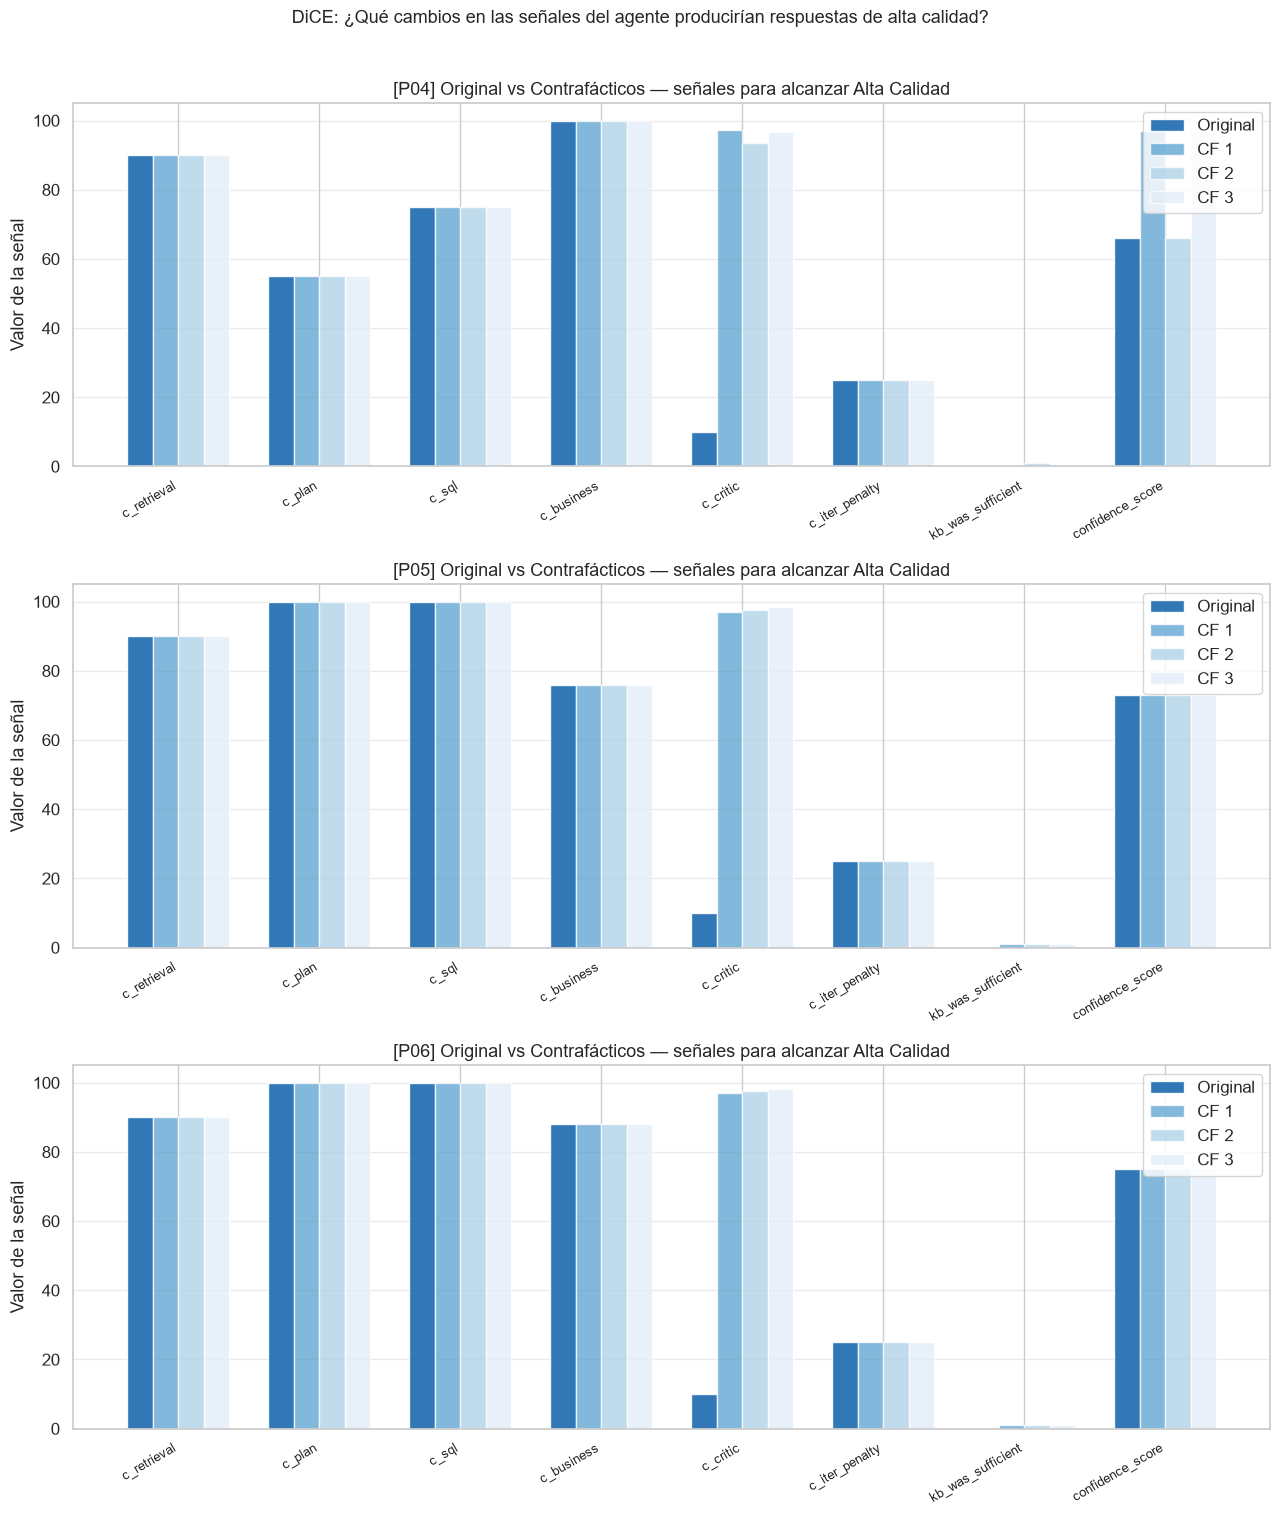


📋 Cambios necesarios (Delta = CF − Original):

  [P04]
    CF 1: c_critic: 10.0→97.4 (Δ+87.4) | confidence_score: 66.0→97.1 (Δ+31.1)
    CF 2: c_critic: 10.0→93.5 (Δ+83.5) | kb_was_sufficient: 0.0→1.0 (Δ+1.0)
    CF 3: c_critic: 10.0→96.8 (Δ+86.8) | confidence_score: 66.0→96.9 (Δ+30.9)

  [P05]
    CF 1: c_critic: 10.0→97.1 (Δ+87.1) | kb_was_sufficient: 0.0→1.1 (Δ+1.1)
    CF 2: c_critic: 10.0→97.7 (Δ+87.7) | kb_was_sufficient: 0.0→1.1 (Δ+1.1)
    CF 3: c_critic: 10.0→98.3 (Δ+88.3) | kb_was_sufficient: 0.0→1.1 (Δ+1.1)

  [P06]
    CF 1: c_critic: 10.0→97.1 (Δ+87.1) | kb_was_sufficient: 0.0→1.1 (Δ+1.1)
    CF 2: c_critic: 10.0→97.7 (Δ+87.7) | kb_was_sufficient: 0.0→1.1 (Δ+1.1)
    CF 3: c_critic: 10.0→98.3 (Δ+88.3) | kb_was_sufficient: 0.0→1.1 (Δ+1.1)



In [24]:
# ── Visualización: Original vs Contrafácticos ─────────────────────────────────
if not cf_results:
    print("⚠️  No se generaron contrafácticos.")
else:
    n_cases = len(cf_results)
    fig, axes = plt.subplots(n_cases, 1, figsize=(13, 5 * n_cases), squeeze=False)

    for row_idx, result in enumerate(cf_results):
        ax = axes[row_idx, 0]

        orig_vals = result["original"][SIGNAL_COLS].values[0].astype(float)

        # DiCE puede devolver columnas extra (quality_class) — filtramos solo SIGNAL_COLS
        cf_df_clean = result["cfs"][[c for c in SIGNAL_COLS if c in result["cfs"].columns]]
        cf_vals     = cf_df_clean.values.astype(float)

        x     = np.arange(len(SIGNAL_COLS))
        width = 0.18

        ax.bar(x - 1.5*width, orig_vals, width, label="Original",
               color=COLOR_PALETTE[1], alpha=0.9)
        for k, (cf_row, color) in enumerate(
            zip(cf_vals, [COLOR_PALETTE[3], COLOR_PALETTE[5], COLOR_PALETTE[7]])
        ):
            ax.bar(x + (k - 0.5)*width, cf_row, width,
                   label=f"CF {k+1}", color=color, alpha=0.75)

        ax.set_xticks(x)
        ax.set_xticklabels(SIGNAL_COLS, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Valor de la señal")
        ax.set_title(
            f"[{result['id']}] Original vs Contrafácticos "
            f"— señales para alcanzar Alta Calidad"
        )
        ax.legend(loc="upper right")
        ax.grid(axis="y", alpha=0.4)

    plt.suptitle(
        "DiCE: ¿Qué cambios en las señales del agente producirían respuestas de alta calidad?",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()

    # ── Tabla de deltas ───────────────────────────────────────────────────────
    print("\n📋 Cambios necesarios (Delta = CF − Original):\n")
    for result in cf_results:
        orig    = result["original"][SIGNAL_COLS].values[0].astype(float)
        cf_df_c = result["cfs"][[c for c in SIGNAL_COLS if c in result["cfs"].columns]]
        print(f"  [{result['id']}]")
        for k, cf_row in enumerate(cf_df_c.values.astype(float)):
            deltas  = cf_row - orig
            changed = [
                f"{SIGNAL_COLS[i]}: {orig[i]:.1f}→{cf_row[i]:.1f} (Δ{deltas[i]:+.1f})"
                for i in range(len(SIGNAL_COLS)) if abs(deltas[i]) > 0.5
            ]
            print(f"    CF {k+1}: {' | '.join(changed) if changed else 'sin cambios significativos'}")
        print()

# Punto 4: Resultados y Discusión


## 4.1 Resultados SHAP — ¿Qué señales determinan la calidad?

El análisis de explicabilidad con SHAP muestra que la variable con mayor influencia en la predicción de respuestas de alta calidad es `c_critic`, lo que confirma que la evaluación realizada por el agente crítico es el mejor indicador de calidad. En segundo lugar, `confidence_score` demuestra que el mecanismo de autoevaluación resume de forma efectiva el estado del pipeline y aporta información relevante al modelo. Por otro lado, `c_iter_penalty`tiene un impacto negativo, indicando que las consultas que requieren varios intentos suelen estar asociadas con respuestas de menor calidad. Finalmente, `kb_was_sufficient` contribuye positivamente cuando la consulta puede resolverse directamente desde la base de conocimiento, lo que respalda que las decisiones tomadas por el validador de conocimiento son, en general, correctas.

---

## 4.2 Resultados DiCE — ¿Cómo mejorar una respuesta de baja calidad?

El análisis contrafáctico con DiCE permitió identificar qué cambios habrían sido necesarios para que respuestas clasificadas como de baja calidad pasaran a ser de alta calidad. En la mayoría de los casos, los contrafácticos proponen incrementar `c_critic` y `confidence_score`, mientras que las modificaciones en `c_sql` y `c_business` son mínimas, lo que sugiere que el problema no suele estar en la generación del SQL o en la lógica de negocio, sino en que el agente no fue lo suficientemente crítico al validar su propia respuesta. Además, varios escenarios indican que la consulta habría obtenido mejores resultados siguiendo directamente la ruta de la base de conocimiento (`kb_was_sufficient`), lo que abre la posibilidad de ajustar el umbral del Validador KB. Finalmente, la diversidad de los contrafácticos muestra que existen múltiples formas de mejorar la calidad de las respuestas, lo cual es consistente con la naturaleza de una arquitectura basada en agentes especializados.


# Punto 5: Conclusiones


En este trabajo logramos hacer transparente el proceso de toma de decisiones del agente, permitiendo entender no solo qué responde, sino también qué factores influyen en la calidad de sus respuestas. Con **SHAP** identificamos que los elementos con mayor impacto no son únicamente los relacionados con la generación del SQL, sino principalmente la capacidad crítica del agente y su nivel de confianza al evaluar sus propias respuestas. Por su parte, **DiCE** permitió ir un paso más allá al mostrar qué cambios concretos podrían convertir una respuesta de baja calidad en una de alta calidad, proporcionando recomendaciones útiles para optimizar el comportamiento del sistema. En conjunto, este enfoque demuestra que las técnicas de explicabilidad no solo incrementan la transparencia del agente, sino que también generan información práctica para mejorar su desempeño y fortalecer la confianza en su uso dentro de un entorno empresarial.
